# U-Net

In [1]:
# Mount Google Drive to access the data
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install necessary libraries
!pip install rasterio torchmetrics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 99.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 64.1 MB/s eta 0:00:00


In [6]:
import os
import tarfile
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from glob import glob
import rasterio
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn.functional as F
from torchmetrics import R2Score

In [7]:
VERSION = '5_WL_test'

In [32]:
class Config:

    ########### ADJUST #############
    DRIVE_BASE_PATH = "/content/drive/MyDrive/Colab_Notebooks/Datasets/BioMassters/tar_gz_archives" # Data paths on Google Drive
    FEATURES_TRAIN = "S1_July_train_features.tar.gz"
    FEATURES_TEST = "S1_July_test_features.tar.gz"
    LABELS_TRAIN = "train_agbm.tar.gz"
    LABELS_TEST = "test_agbm.tar.gz"

    # Input data archives
    S1_TRAIN_ARCHIVE = os.path.join(DRIVE_BASE_PATH, FEATURES_TRAIN)
    S1_TEST_ARCHIVE = os.path.join(DRIVE_BASE_PATH, FEATURES_TEST)

    # Label data archives
    AGB_TRAIN_ARCHIVE = os.path.join(DRIVE_BASE_PATH, LABELS_TRAIN)
    AGB_TEST_ARCHIVE = os.path.join(DRIVE_BASE_PATH, LABELS_TEST)

    # Local Colab paths for extracted data
    LOCAL_DATA_PATH = "/content/data"
    S1_TRAIN_PATH = os.path.join(LOCAL_DATA_PATH, "s1_train")
    S1_TEST_PATH = os.path.join(LOCAL_DATA_PATH, "s1_test")
    AGB_TRAIN_PATH = os.path.join(LOCAL_DATA_PATH, "agb_train")
    AGB_TEST_PATH = os.path.join(LOCAL_DATA_PATH, "agb_test")

    USE_WEIGHTED_LOSS = True
    LOSS_PERCENTILE = 99.0
    LP1= str(LOSS_PERCENTILE).split('.')[0]
    LP2 = str(LOSS_PERCENTILE).split('.')[1]
    LOSS_HIGH_WEIGHT = 10.0
    LF1 = str(LOSS_HIGH_WEIGHT).split('.')[0]
    LF2 = str(LOSS_HIGH_WEIGHT).split('.')[1]

    # Training parameters
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    NUM_EPOCHS = 40
    BATCH_SIZE = 16
    LEARNING_RATE = 1e-4
    #WEIGHT_DECAY = 1e-5
    WEIGHT_DECAY = 0 # Weight decay deactivated
    NUM_WORKERS = 4 # Colab usually has 2 CPU cores
    PIN_MEMORY = True
    SEED = 42

    # Early stopping
    EARLY_STOPPING_PATIENCE = 5

    # Path to save results on Google Drive
    MODEL_NAME = f"UNet_v{VERSION}_PERC{LP1}-{LP2}_LF{LF1}-{LF2}_EP{NUM_EPOCHS}_BS{BATCH_SIZE}_LR{str(LEARNING_RATE).split('.')[1]}_SEED{SEED}"
    #MODEL_NAME = f"UNet_v{VERSION}_EP{NUM_EPOCHS}_BS{BATCH_SIZE}_LR{str(LEARNING_RATE).split('.')[1]}_SEED{SEED}"
    #MODEL_NAME = f"UNet_v{VERSION}_EP{NUM_EPOCHS}_BS{BATCH_SIZE}_LR{str(LEARNING_RATE).split('.')[1]}_WDC{f"{WEIGHT_DECAY:5f}".split('.')[1][:5]}_SEED{SEED}"
    #MODEL_NAME = f"UNet_v{VERSION}_EP{NUM_EPOCHS}_BS{BATCH_SIZE}_LR{str(LEARNING_RATE).split('.')[1]}_WDC{f"{WEIGHT_DECAY:5f}".split('.')[1][:5]}"
    print(MODEL_NAME)
    OUTPUT_DIR = os.path.join(f"/content/drive/MyDrive/Colab_Notebooks/Training/baseline_models/UNet", MODEL_NAME)
    STATS_FILE = os.path.join("/content/drive/MyDrive/Colab_Notebooks/Training/baseline_models/UNet", "norm_stats.pt")


# Create the config object and output directory
config = Config()
os.makedirs(config.OUTPUT_DIR, exist_ok=True)

print(f"Using device: {config.DEVICE}")
if config.DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

UNet_v5_WL_test_PERC99-0_LF10-0_EP40_BS16_LR0001_SEED42
Using device: cuda
GPU: NVIDIA A100-SXM4-80GB


### Clearing CUDA cache from previous runs to release all available GPU memory capacity

In [33]:
import torch
import gc

# Run Python's garbage collector
gc.collect()

# Tell PyTorch to release the cached memory
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("PyTorch CUDA cache has been cleared.")

# You can now re-run the GPU Analysis cell to confirm the memory has been freed.

PyTorch CUDA cache has been cleared.


In [34]:
import torch

# This cell analyzes the available GPU hardware.
if torch.cuda.is_available():
    # Get the current device ID
    device_id = torch.cuda.current_device()

    # Get the device properties
    gpu_properties = torch.cuda.get_device_properties(device_id)
    gpu_name = gpu_properties.name
    total_vram_gb = gpu_properties.total_memory / (1024**3)

    # Get the currently free memory, which is a better indicator of what's usable
    # This accounts for memory already used by the CUDA context, etc.
    free_vram_bytes, _ = torch.cuda.mem_get_info(device_id)
    available_vram_gb = free_vram_bytes / (1024**3)

    # Define a safety margin (e.g., use 90% of available VRAM) to prevent crashes
    usable_vram_gb = available_vram_gb * 0.90

    print("--- GPU Analysis ---")
    print(f"✅ Detected GPU: {gpu_name}")
    print(f"   - Total VRAM:      {total_vram_gb:.2f} GB")
    print(f"   - Available VRAM:  {available_vram_gb:.2f} GB")
    print(f"   - Usable (w/ 90% safety margin): {usable_vram_gb:.2f} GB")
    print("--------------------")

else:
    gpu_name = "N/A"
    usable_vram_gb = 0
    print("❌ No GPU detected. The model will run on the CPU.")

--- GPU Analysis ---
✅ Detected GPU: NVIDIA A100-SXM4-80GB
   - Total VRAM:      79.32 GB
   - Available VRAM:  77.84 GB
   - Usable (w/ 90% safety margin): 70.05 GB
--------------------


In [35]:
def seed_everything(seed: int):
    """
    Sets the seed for all relevant random number generators to ensure reproducibility.
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if you are using multi-GPU.
    # The two lines below are known to be necessary for full reproducibility
    # with CUDA, but they can slow down training.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Global seed set to {seed}")

# Set the seed for the entire session
seed_everything(config.SEED)

Global seed set to 42


In [36]:
def extract_tar_gz(tar_path, extract_path):
    """Helper function to extract a .tar.gz archive."""
    print(f"Extracting {os.path.basename(tar_path)} to {extract_path}...")
    if not os.path.exists(extract_path):
        os.makedirs(extract_path)
    with tarfile.open(tar_path, 'r:gz') as tar:
        tar.extractall(path=extract_path)
    print("Extraction complete.")

# --- Main Logic: Check if data is already extracted in this session ---
# We check for the existence of the final directories in Colab's local storage.
if os.path.exists(config.S1_TRAIN_PATH) and len(os.listdir(config.S1_TRAIN_PATH)) > 0:
    print("Data directories already exist and are not empty in Colab's local storage.")
    print(f"Found {len(os.listdir(config.S1_TRAIN_PATH))} files in {os.path.basename(config.S1_TRAIN_PATH)}")
    print(f"Found {len(os.listdir(config.S1_TEST_PATH))} files in {os.path.basename(config.S1_TEST_PATH)}")
    print("Skipping copy and extraction.")
else:
    print("Data not found in local storage. Starting copy and extraction process...")

    # Copy and extract training data
    print("--- Preparing Training Data ---")
    !cp "{config.S1_TRAIN_ARCHIVE}" .
    !cp "{config.AGB_TRAIN_ARCHIVE}" .
    extract_tar_gz(config.FEATURES_TRAIN, config.S1_TRAIN_PATH)
    extract_tar_gz(config.LABELS_TRAIN, config.AGB_TRAIN_PATH)

    # Copy and extract test/validation data
    print("\n--- Preparing Test/Validation Data ---")
    !cp "{config.S1_TEST_ARCHIVE}" .
    !cp "{config.AGB_TEST_ARCHIVE}" .
    extract_tar_gz(config.FEATURES_TEST, config.S1_TEST_PATH)
    extract_tar_gz(config.LABELS_TEST, config.AGB_TEST_PATH)

    # --- Clean up local archives to save space ---
    !rm *.tar.gz
    print("\nData preparation complete.")

Data directories already exist and are not empty in Colab's local storage.
Found 8689 files in s1_train
Found 2773 files in s1_test
Skipping copy and extraction.


In [37]:
from sklearn.model_selection import train_test_split
import random

# --- This cell prepares the file lists for training, validation, and testing ---

# 1. Find all file pairs in the original training directory
print("Creating file lists...")
s1_train_files_all = sorted(glob(os.path.join(config.S1_TRAIN_PATH, "*_S1_10.tif")))
agb_files_all = {os.path.basename(f).split('_')[0]: f for f in glob(os.path.join(config.AGB_TRAIN_PATH, "*_agbm.tif"))}

all_train_val_pairs = []
for s1_file in s1_train_files_all:
    s1_id = os.path.basename(s1_file).split('_')[0]
    if s1_id in agb_files_all:
        all_train_val_pairs.append((s1_file, agb_files_all[s1_id]))

# 2. Shuffle and split the list into new training and validation sets
random.seed(config.SEED) # Use the global seed for a reproducible split
random.shuffle(all_train_val_pairs)

split_ratio = 0.8
split_index = int(len(all_train_val_pairs) * split_ratio)

train_file_pairs = all_train_val_pairs[:split_index]
val_file_pairs = all_train_val_pairs[split_index:]

print(f"Total samples for Train/Val: {len(all_train_val_pairs)}")
print(f"--> Training samples:   {len(train_file_pairs)}")
print(f"--> Validation samples: {len(val_file_pairs)}")

# 3. Create the file list for the final, held-out test set
s1_test_files = sorted(glob(os.path.join(config.S1_TEST_PATH, "*_S1_10.tif")))
agb_test_files_map = {os.path.basename(f).split('_')[0]: f for f in glob(os.path.join(config.AGB_TEST_PATH, "*_agbm.tif"))}
test_file_pairs = []
for s1_file in s1_test_files:
    s1_id = os.path.basename(s1_file).split('_')[0]
    if s1_id in agb_test_files_map:
        test_file_pairs.append((s1_file, agb_test_files_map[s1_id]))

print(f"--> Inference Test samples: {len(test_file_pairs)}")

Creating file lists...
Total samples for Train/Val: 8689
--> Training samples:   6951
--> Validation samples: 1738
--> Inference Test samples: 2773


In [38]:
class ForestDataset(Dataset):

    def __init__(self, file_pairs, transform=None):
        self.file_pairs = file_pairs
        self.transform = transform
        print(f"Initialized dataset with {len(self.file_pairs)} samples.")

    def __len__(self):
        return len(self.file_pairs)

    def __getitem__(self, idx):
        s1_path, agb_path = self.file_pairs[idx]

        # Read Sentinel-1 SAR data (first two bands)
        with rasterio.open(s1_path) as src:
            s1_image = src.read([1, 2]).astype(np.float32)

        # Read AGB label data
        with rasterio.open(agb_path) as src:
            agb_image = src.read(1).astype(np.float32)
            agb_image = np.expand_dims(agb_image, axis=0)

        s1_tensor = torch.from_numpy(s1_image)
        agb_tensor = torch.from_numpy(agb_image)

        if self.transform:
            stacked = torch.cat((s1_tensor, agb_tensor), dim=0)
            stacked = self.transform(stacked)
            s1_tensor = stacked[:2, :, :]
            agb_tensor = stacked[2:, :, :]

        return s1_tensor, agb_tensor

# Define on-the-fly transformations for training data (augmentation)
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
])

In [39]:
# This helper function is still needed for the first run
def get_normalization_stats(dataloader):
    print("Calculating normalization statistics from the training set...")
    channels_sum, channels_squared_sum, num_batches = 0, 0, 0

    for data, _ in tqdm(dataloader):
        # data shape is [B, C, H, W]
        channels_sum += torch.mean(data, dim=[0, 2, 3])
        channels_squared_sum += torch.mean(data**2, dim=[0, 2, 3])
        num_batches += 1

    mean = channels_sum / num_batches
    std = (channels_squared_sum / num_batches - mean**2)**0.5

    return mean, std

# --- Main Logic: Load if exists, otherwise calculate and save ---
if os.path.exists(config.STATS_FILE):
    print(f"Loading normalization statistics from {config.STATS_FILE}...")
    stats = torch.load(config.STATS_FILE)
    S1_MEAN = stats['mean']
    S1_STD = stats['std']
    print("Statistics loaded successfully.")
else:
    print(f"Statistics file not found at {config.STATS_FILE}. Calculating from scratch...")

    # Create a temporary dataset and dataloader JUST for calculating stats
    temp_train_dataset = ForestDataset(s1_dir=config.S1_TRAIN_PATH, agb_dir=config.AGB_TRAIN_PATH)
    temp_train_loader = DataLoader(
        temp_train_dataset,
        batch_size=config.BATCH_SIZE,
        num_workers=config.NUM_WORKERS
    )

    # Calculate stats
    S1_MEAN, S1_STD = get_normalization_stats(temp_train_loader)

    # Save the calculated stats to Google Drive for future use
    print(f"Saving normalization statistics to {config.STATS_FILE}...")
    torch.save({'mean': S1_MEAN, 'std': S1_STD}, config.STATS_FILE)
    print("Statistics saved for future sessions.")

# Finally, move the loaded or calculated stats to the correct device
S1_MEAN = S1_MEAN.to(config.DEVICE)
S1_STD = S1_STD.to(config.DEVICE)

print(f"\nUsing Mean: {S1_MEAN.cpu().numpy()}")
print(f"Using Std: {S1_STD.cpu().numpy()}")

Loading normalization statistics from /content/drive/MyDrive/Colab_Notebooks/Training/baseline_models/UNet/norm_stats.pt...
Statistics loaded successfully.

Using Mean: [-10.965339 -17.10035 ]
Using Std: [3.3277776 4.478529 ]


In [40]:
class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    """Downscaling with maxpool then double conv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    """Upscaling then double conv"""
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffY = x2.size()[2] - x1.size()[2] # calculate potential size misalignments
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2]) # compensate potential size misalignments by padding
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        # We add a ReLU to ensure the output (biomass) is non-negative
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.conv(x))

class UNet(nn.Module):
    def __init__(self, n_channels, n_classes, bilinear=True):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128) # 128 x 128
        self.down2 = Down(128, 256) # 64 x 64
        self.down3 = Down(256, 512) # 32 x 32
        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor) # 16 x 16

        self.dropout = nn.Dropout(p=0.5) # A common 50% probability

        self.up1 = Up(1024, 512 // factor, bilinear)
        self.up2 = Up(512, 256 // factor, bilinear)
        self.up3 = Up(256, 128 // factor, bilinear)
        self.up4 = Up(128, 64, bilinear)
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x5 = self.dropout(x5)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

In [41]:
class WeightedMSELoss(nn.Module):
    """
    Calculates a weighted Mean Squared Error, applying a higher weight
    to errors on pixels where the target value is above a given threshold.
    """
    def __init__(self, threshold, high_weight_factor):
        super().__init__()
        self.threshold = threshold
        self.high_weight = high_weight_factor
        print(f"Initialized WeightedMSELoss: weight={self.high_weight} for targets > {self.threshold}")

    def forward(self, predictions, targets):
        # Calculate standard pixel-wise squared errors without reduction
        squared_errors = F.mse_loss(predictions, targets, reduction='none')

        # Create a weight map, default weight is 1
        weights = torch.ones_like(targets)

        # Apply the high weight where the target is above the threshold
        weights[targets > self.threshold] = self.high_weight

        # Apply the weights to the errors and calculate the final mean
        weighted_loss = squared_errors * weights

        return torch.mean(weighted_loss)

In [42]:
class EarlyStopping:
    def __init__(self, patience=7, verbose=False, delta=0, path='checkpoint.pth'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

def train_fn(loader, model, optimizer, loss_fn, scaler, normalizer):
    loop = tqdm(loader, leave=True, desc="Training")
    running_loss = 0.0

    model.train()
    for batch_idx, (data, targets) in enumerate(loop):
        data = data.to(device=config.DEVICE)
        targets = targets.to(device=config.DEVICE)

        # Normalize the input data
        data = normalizer(data)

        # Forward
        with torch.cuda.amp.autocast():
            predictions = model(data)
            loss = loss_fn(predictions, targets)

        # Backward
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    return running_loss / len(loader)

def validate_fn(loader, model, loss_fn, normalizer):
    model.eval()
    val_loss = 0.0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for data, targets in loader:
            data = data.to(device=config.DEVICE)
            targets = targets.to(device=config.DEVICE)

            # Normalize
            data = normalizer(data)

            predictions = model(data)
            loss = loss_fn(predictions, targets)
            val_loss += loss.item()

            # Flatten and collect for metrics
            all_preds.append(predictions.view(-1))
            all_targets.append(targets.view(-1))

    # Concatenate all batches
    all_preds = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)

    # Calculate metrics
    mae = F.l1_loss(all_preds, all_targets).item()
    rmse = torch.sqrt(F.mse_loss(all_preds, all_targets)).item()
    r2_metric = R2Score().to(config.DEVICE)
    r2 = r2_metric(all_preds, all_targets).item()

    avg_val_loss = val_loss / len(loader)

    print(f"Validation => Avg Loss: {avg_val_loss:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

    return avg_val_loss, rmse, mae, r2

### Choice of loss fn

In [43]:
import numpy as np
from tqdm.notebook import tqdm

# --- This cell sets up the loss function based on the Config settings ---

# The WeightedMSELoss class must be defined in a cell above this one.
if config.USE_WEIGHTED_LOSS:
    print("--- Setting up Weighted MSE Loss ---")

    # 1. Calculate the AGB threshold dynamically
    print(f"Calculating the {config.LOSS_PERCENTILE}th percentile AGB threshold...")
    # Create a temporary loader to quickly iterate through the data
    temp_loader = DataLoader(ForestDataset(file_pairs=train_file_pairs), batch_size=config.BATCH_SIZE, num_workers=config.NUM_WORKERS)

    # Concatenate all target values from the training set
    all_agb_values = np.concatenate([targets.numpy().flatten() for _, targets in tqdm(temp_loader, desc="Analyzing AGB values")])

    # Calculate the percentile from the config
    agb_percentile_threshold = np.percentile(all_agb_values, config.LOSS_PERCENTILE)

    print(f"Threshold determined: {agb_percentile_threshold:.2f} tons/pixel")

    # 2. Instantiate the custom loss function
    loss_fn = WeightedMSELoss(
        threshold=agb_percentile_threshold,
        high_weight_factor=config.LOSS_HIGH_WEIGHT
    )

    # Clean up to free memory
    del temp_loader, all_agb_values

else:
    print("--- Setting up Standard MSE Loss ---")
    loss_fn = nn.MSELoss()

# The 'loss_fn' variable is now defined and ready for the main training loop.

--- Setting up Weighted MSE Loss ---
Calculating the 99.0th percentile AGB threshold...
Initialized dataset with 6951 samples.


Analyzing AGB values:   0%|          | 0/435 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


Threshold determined: 304.41 tons/pixel
Initialized WeightedMSELoss: weight=10.0 for targets > 304.4100036621094


In [44]:
# --- This cell is updated to use the new train/val/test splits ---

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

# 1. Create the datasets using the pre-split file lists
train_dataset = ForestDataset(file_pairs=train_file_pairs, transform=None) # deactivated data augmentation
val_dataset = ForestDataset(file_pairs=val_file_pairs) # No transforms for validation
test_dataset = ForestDataset(file_pairs=test_file_pairs)   # No transforms for final testing

# 2. Create the DataLoaders
g = torch.Generator()
g.manual_seed(config.SEED)

train_loader = DataLoader(
    train_dataset, batch_size=config.BATCH_SIZE, num_workers=config.NUM_WORKERS,
    pin_memory=config.PIN_MEMORY, shuffle=True, worker_init_fn=seed_worker, generator=g
)
val_loader = DataLoader(
    val_dataset, batch_size=config.BATCH_SIZE, num_workers=config.NUM_WORKERS,
    pin_memory=config.PIN_MEMORY, shuffle=False
)
# New loader for the final test set
test_loader = DataLoader(
    test_dataset, batch_size=config.BATCH_SIZE, num_workers=config.NUM_WORKERS,
    pin_memory=config.PIN_MEMORY, shuffle=False
)

# --- The rest of the cell (model init, optimizer, training loop) remains the same ---
model = UNet(n_channels=2, n_classes=1, bilinear=False).to(config.DEVICE) # Example with bilinear=False
optimizer = optim.AdamW(model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)
scaler = torch.cuda.amp.GradScaler()
normalize_transform = transforms.Normalize(mean=S1_MEAN, std=S1_STD)
best_model_path = os.path.join(config.OUTPUT_DIR, 'best_model.pth')
early_stopper = EarlyStopping(patience=config.EARLY_STOPPING_PATIENCE, verbose=True, path=best_model_path)
history = {'train_loss': [], 'val_loss': [], 'val_rmse': [], 'val_mae': [], 'val_r2': []}

Initialized dataset with 6951 samples.
Initialized dataset with 1738 samples.
Initialized dataset with 2773 samples.


/tmp/ipython-input-4140582690.py:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


# Estimating max batch size

In [45]:
import torch.nn.functional as F

def estimate_max_batch_size(model, optimizer, usable_vram_gb, input_shape=(2, 256, 256)):
    """
    Estimates the maximum possible batch size for a model given the available VRAM.
    This version uses a more robust heuristic without a fixed overhead assumption.
    """
    if config.DEVICE == 'cpu':
        print("Batch size estimation is not applicable for CPU.")
        return

    print("\n--- Max Batch Size Estimator (v3 - Corrected) ---")

    model.to(config.DEVICE)
    gb_divisor = 1024**3

    # 1. Calculate Static Memory (Model Parameters + Optimizer States)
    param_size_bytes = sum(p.numel() * 4 for p in model.parameters())
    optim_size_bytes = sum(p.numel() * 8 for p in model.parameters())
    static_memory_gb = (param_size_bytes + optim_size_bytes) / gb_divisor
    print(f"Estimated Static Memory (Model + Optimizer): {static_memory_gb:.3f} GB")

    # 2. Measure Dynamic Memory by running a test batch
    test_batch_size = 2
    dummy_input = torch.randn(test_batch_size, *input_shape, dtype=torch.float32).to(config.DEVICE)
    dummy_target = torch.randn(test_batch_size, 1, *input_shape[1:], dtype=torch.float32).to(config.DEVICE)
    torch.cuda.reset_peak_memory_stats()

    try:
        # Perform a full pass to get a realistic memory peak
        with torch.amp.autocast(device_type="cuda"):
            output = model(dummy_input)
            loss = F.mse_loss(output, dummy_target)

        # --- CORRECTED LINE ---
        # The GradScaler constructor does not take a 'device_type' argument.
        scaler = torch.amp.GradScaler()
        # --- END OF CORRECTION ---

        scaler.scale(loss).backward()
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)

        peak_memory_gb = torch.cuda.max_memory_allocated() / gb_divisor

        dynamic_memory_gb = peak_memory_gb - static_memory_gb
        memory_per_sample_gb = dynamic_memory_gb / test_batch_size

        print(f"Peak memory for Batch Size={test_batch_size}: {peak_memory_gb:.3f} GB")
        print(f"Estimated Memory per Sample (Activations + Overhead): {memory_per_sample_gb:.3f} GB")

        # 3. Calculate and Recommend Max Batch Size
        vram_available_for_dynamic_mem = usable_vram_gb - static_memory_gb

        if vram_available_for_dynamic_mem > 0 and memory_per_sample_gb > 0:
            estimated_max_bs = int(vram_available_for_dynamic_mem / memory_per_sample_gb)
            print("\n---------------------------------------------------------")
            print(f"---> 💡 Estimated Max Batch Size: {estimated_max_bs} <---")
            print("---------------------------------------------------------")
        else:
            print("\n---> ⚠️ Could not estimate batch size. The static memory may be too high.")

    except RuntimeError as e:
        if "out of memory" in str(e):
            print("\n---> ❌ CUDA out of memory even with a small test batch.")
        else:
            raise e
    finally:
        del dummy_input, dummy_target
        torch.cuda.empty_cache()

# --- HOW TO USE IT ---
# Call this function after initializing your model and optimizer.
estimate_max_batch_size(model, optimizer, usable_vram_gb)


--- Max Batch Size Estimator (v3 - Corrected) ---
Estimated Static Memory (Model + Optimizer): 0.347 GB
Peak memory for Batch Size=2: 0.708 GB
Estimated Memory per Sample (Activations + Overhead): 0.180 GB

---------------------------------------------------------
---> 💡 Estimated Max Batch Size: 386 <---
---------------------------------------------------------


# TRAINING LOOP

In [46]:
# --- TRAINING LOOP ---
for epoch in range(config.NUM_EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{config.NUM_EPOCHS} ---")

    train_loss = train_fn(train_loader, model, optimizer, loss_fn, scaler, normalize_transform)
    val_loss, val_rmse, val_mae, val_r2 = validate_fn(val_loader, model, loss_fn, normalize_transform)

    # Store history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_rmse'].append(val_rmse)
    history['val_mae'].append(val_mae)
    history['val_r2'].append(val_r2)

    # Early stopping check
    early_stopper(val_loss, model)
    if early_stopper.early_stop:
        print("Early stopping triggered!")
        break

# Save training history
history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(config.OUTPUT_DIR, 'training_history.csv'), index=False)
print("\nTraining complete. Best model and history saved.")


--- Epoch 1/40 ---


Training:   0%|          | 0/435 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/tmp/ipython

Validation => Avg Loss: 21927.0872, RMSE: 95.5367, MAE: 63.3519, R²: -0.7515
Validation loss decreased (inf --> 21927.087237). Saving model...

--- Epoch 2/40 ---


Training:   0%|          | 0/435 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/l

Validation => Avg Loss: 6063.4539, RMSE: 51.1423, MAE: 30.6382, R²: 0.4981
Validation loss decreased (6187.257945 --> 6063.453871). Saving model...

--- Epoch 40/40 ---


Training:   0%|          | 0/435 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/l

Validation => Avg Loss: 6101.9521, RMSE: 48.2562, MAE: 28.7780, R²: 0.5531
EarlyStopping counter: 1 out of 5

Training complete. Best model and history saved.


# Plots of metrics

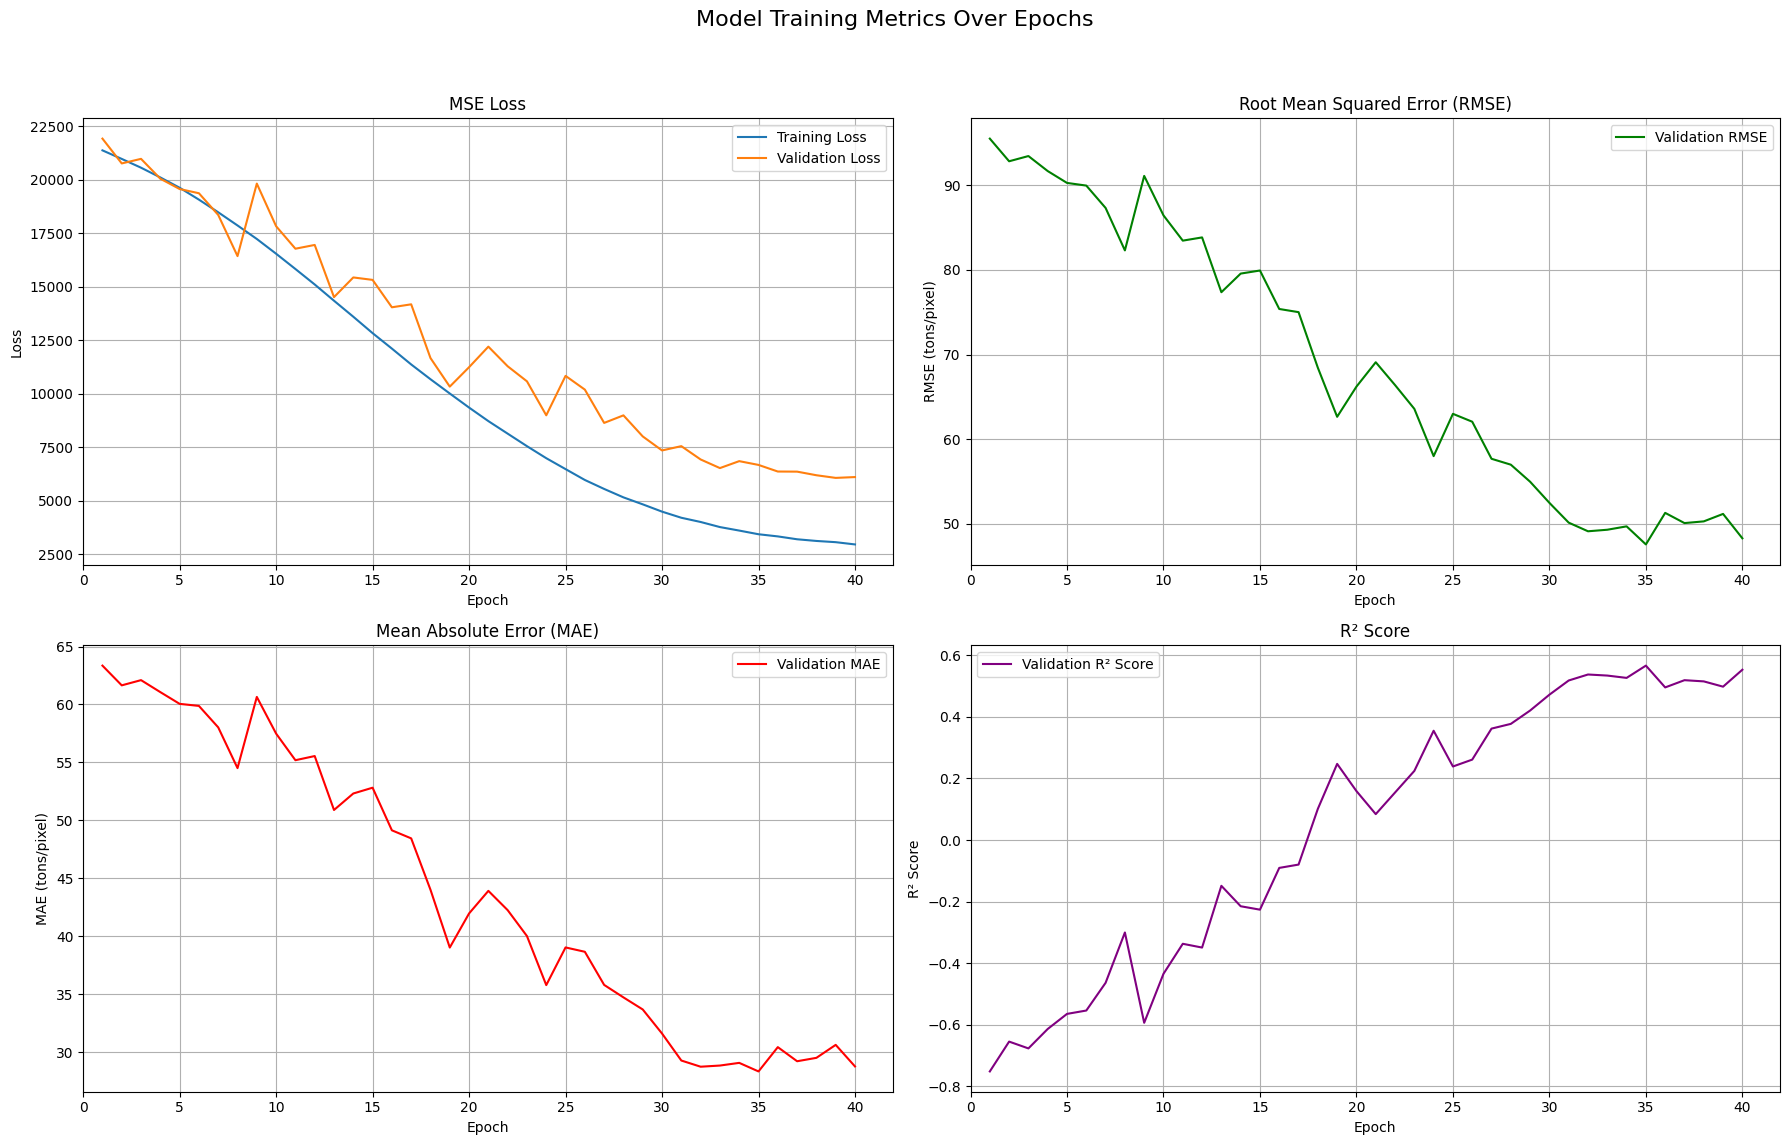

In [47]:


# This cell is now self-contained and works on any runtime.
# It has been corrected to display epochs starting from 1, while keeping 0 on the x-axis.

def plot_metrics_from_csv(history_path, output_path):
    """Loads history from a CSV file and plots the metrics with 1-based epoch numbering."""
    if not os.path.exists(history_path):
        print(f"Error: Training history file not found at {history_path}")
        return

    history_df = pd.read_csv(history_path)

    # Create a 1-based epoch count for the x-axis
    epochs = history_df.index + 1

    fig, axs = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Model Training Metrics Over Epochs', fontsize=16)

    # Loss (MSE)
    axs[0, 0].plot(epochs, history_df['train_loss'], label='Training Loss')
    axs[0, 0].plot(epochs, history_df['val_loss'], label='Validation Loss')
    axs[0, 0].set_title('MSE Loss')
    axs[0, 0].set_xlabel('Epoch')
    axs[0, 0].set_ylabel('Loss')
    axs[0, 0].legend()
    axs[0, 0].grid(True)

    # RMSE
    axs[0, 1].plot(epochs, history_df['val_rmse'], label='Validation RMSE', color='green')
    axs[0, 1].set_title('Root Mean Squared Error (RMSE)')
    axs[0, 1].set_xlabel('Epoch')
    axs[0, 1].set_ylabel('RMSE (tons/pixel)')
    axs[0, 1].legend()
    axs[0, 1].grid(True)

    # MAE
    axs[1, 0].plot(epochs, history_df['val_mae'], label='Validation MAE', color='red')
    axs[1, 0].set_title('Mean Absolute Error (MAE)')
    axs[1, 0].set_xlabel('Epoch')
    axs[1, 0].set_ylabel('MAE (tons/pixel)')
    axs[1, 0].legend()
    axs[1, 0].grid(True)

    # R2 Score
    axs[1, 1].plot(epochs, history_df['val_r2'], label='Validation R² Score', color='purple')
    axs[1, 1].set_title('R² Score')
    axs[1, 1].set_xlabel('Epoch')
    axs[1, 1].set_ylabel('R² Score')
    axs[1, 1].legend()
    axs[1, 1].grid(True)

    # Set x-axis to start at 0 to include it as a tick mark ---
    if not history_df.empty:
        axs[0, 0].set_xlim(left=0)
        axs[0, 1].set_xlim(left=0)
        axs[1, 0].set_xlim(left=0)
        axs[1, 1].set_xlim(left=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(output_path)
    plt.show()

# --- Execution ---
history_csv_path = os.path.join(config.OUTPUT_DIR, 'training_history.csv')
metrics_plot_path = os.path.join(config.OUTPUT_DIR, 'training_metrics.png')
plot_metrics_from_csv(history_csv_path, metrics_plot_path)

# Visual comparison of Predictions and Targets

In [48]:
# This cell now correctly loads a GPU-trained model onto a CPU.

# The visualization function itself requires no changes.
def visualize_predictions(dataset, model, normalizer, num_samples=5, device='cpu'):
    # Adjust figure size for better spacing. Add space for colorbar and long titles.
    fig, axes = plt.subplots(num_samples, 3, figsize=(18, num_samples * 5.5)) # Increased width and height slightly

    # Adjust suptitle for overall title positioning
    fig.suptitle('Target vs. Prediction Comparison', fontsize=16, y=0.98) # Adjust y to move title up

    # Create an empty list to store handles for colorbar creation later
    ims = []

    for i in range(num_samples):
        idx = random.randint(0, len(dataset) - 1)
        s1, target = dataset[idx]

        # Extract filename (ID) from the s1_path to display as title
        s1_file_path = dataset.file_pairs[idx][0] # Access the full path from the dataset
        s1_filename_id = os.path.basename(s1_file_path).split('_')[0]

        with torch.no_grad():
            s1_input = s1.unsqueeze(0).to(device)
            s1_normalized = normalizer(s1_input)
            prediction = model(s1_normalized).squeeze(0).cpu().numpy()

        s1_display = s1.permute(1, 2, 0).numpy()
        target_display = target.squeeze(0).numpy()
        pred_display = prediction.squeeze(0)

        vmin = min(target_display.min(), pred_display.min())
        vmax = max(target_display.max(), pred_display.max())

        # --- MODIFIED: Input SAR image title ---
        ax_input = axes[i, 0]
        ax_input.imshow(s1_display[:, :, 0], cmap='gray') # VV polarization
        ax_input.set_title(f'Input VV ({s1_filename_id})') # Display filename and VV polarization
        ax_input.axis('off')

        # Plot Target
        ax_target = axes[i, 1]
        im_target = ax_target.imshow(target_display, cmap='viridis', vmin=vmin, vmax=vmax)
        ax_target.set_title(f'Target AGB')
        ax_target.axis('off')

        # Plot Prediction
        ax_pred = axes[i, 2]
        im_pred = ax_pred.imshow(pred_display, cmap='viridis', vmin=vmin, vmax=vmax)
        ax_pred.set_title(f'Predicted AGB')
        ax_pred.axis('off')

        # Store one of the image objects for colorbar creation (they share the same colormap)
        if i == 0: # Only need one image to create the colorbar
            ims.append(im_pred)

    # --- MODIFIED: Layout and Colorbar Position ---
    # Use fig.tight_layout with rect to create space for the colorbar
    # Also adjust subplots_adjust to make room at the bottom/top for titles/labels if needed
    plt.subplots_adjust(right=0.85, wspace=0.1, hspace=0.3) # Adjust right margin for colorbar, and spacing

    # Position the colorbar outside the main axes using the image from the loop
    if ims:
        cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7]) # [left, bottom, width, height]
        fig.colorbar(ims[0], cax=cbar_ax, label='AGB (tons)')
    # --- END OF MODIFICATION ---

    plt.savefig(os.path.join(config.OUTPUT_DIR, 'prediction_visuals.png'))
    plt.show()


# --- Execution ---
# 1. Instantiate the model architecture
#model = UNet(n_channels=2, n_classes=1)
model = UNet(n_channels=2, n_classes=1, bilinear = False)

# 2. Load the saved weights, using map_location to move tensors to the current device
best_model_path = os.path.join(config.OUTPUT_DIR, 'best_model.pth')
model.load_state_dict(torch.load(best_model_path, map_location=torch.device(config.DEVICE)))

# 3. Move the model to the device and set to evaluation mode
model.to(config.DEVICE)
model.eval()
print(f"Model loaded successfully onto device: '{config.DEVICE}'")

# 4. Run visualization
# Create the validation dataset if it doesn't exist
try:
    val_dataset
except NameError:
    print("Creating validation dataset...")
    val_dataset = ForestDataset(s1_dir=config.S1_TEST_PATH, agb_dir=config.AGB_TEST_PATH)

visualize_predictions(test_dataset, model, normalize_transform, num_samples=5, device=config.DEVICE)

Output hidden; open in https://colab.research.google.com to view.

# Density scatter plot

Generating density scatter plot...


Inferencing:   0%|          | 0/174 [00:00<?, ?it/s]

Subsampling points and generating plot...


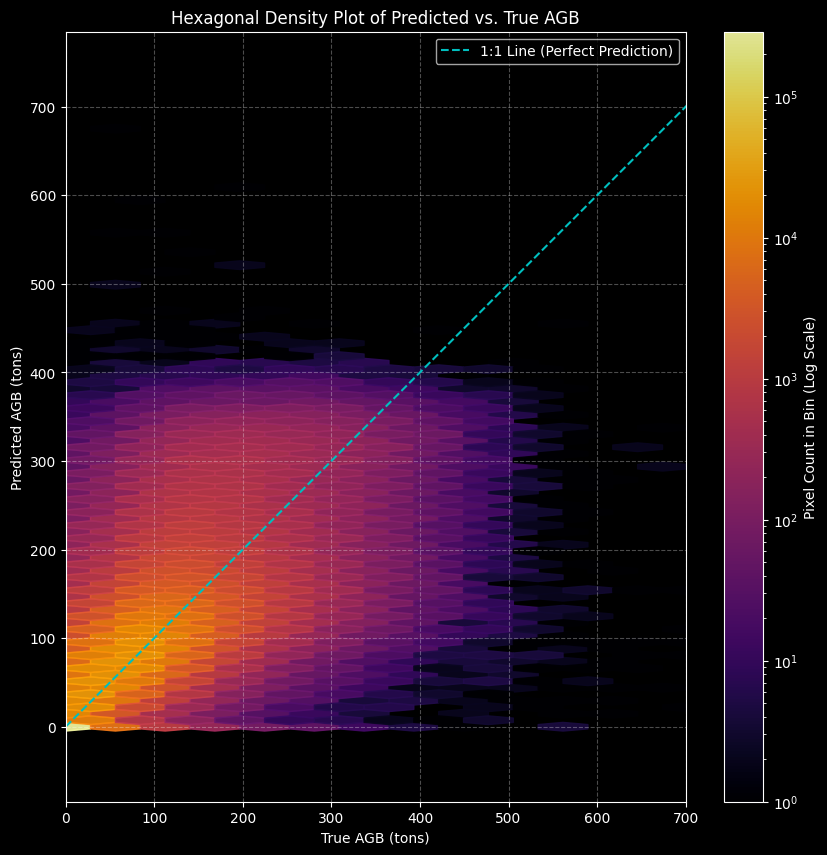

In [49]:
from matplotlib.colors import LogNorm
import math

def create_density_scatter_plot(loader, model, normalizer, device, output_path, limit_batches=None):
    print("Generating density scatter plot...")
    if limit_batches:
        print(f"Running in limited mode: processing a maximum of {limit_batches} batches.")

    model.eval()
    all_targets = []
    all_preds = []

    # Determine the number of batches to loop through
    num_batches = len(loader)
    if limit_batches:
        num_batches = min(limit_batches, num_batches)

    with torch.no_grad():
        # Use enumerate to track the batch count
        for i, (s1, targets) in enumerate(tqdm(loader, total=num_batches, desc="Inferencing")):
            # Stop if the batch limit is reached
            if limit_batches and i >= limit_batches:
                break

            s1 = s1.to(device)
            s1_normalized = normalizer(s1)
            preds = model(s1_normalized)

            all_targets.append(targets.cpu().numpy().flatten())
            all_preds.append(preds.cpu().numpy().flatten())

    all_targets = np.concatenate(all_targets)
    all_preds = np.concatenate(all_preds)

    # The rest of the plotting code remains the same...
    print("Subsampling points and generating plot...")
    if len(all_targets) > 1_000_000:
        idx = np.random.choice(len(all_targets), 1_000_000, replace=False)
        all_targets = all_targets[idx]
        all_preds = all_preds[idx]

    plt.style.use('dark_background')
    plt.figure(figsize=(10, 10))
    plt.hexbin(
        all_targets, all_preds, gridsize=80, cmap='inferno',
        mincnt=1, alpha=0.9, norm=LogNorm()
    )
    max_val = max(all_targets.max(), all_preds.max())
    plt.plot([0, max_val], [0, max_val], 'c--', label='1:1 Line (Perfect Prediction)')
    plt.colorbar(label='Pixel Count in Bin (Log Scale)')
    plt.xlabel('True AGB (tons)')
    plt.ylabel('Predicted AGB (tons)')
    plt.title('Hexagonal Density Plot of Predicted vs. True AGB')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.axis('equal')
    #plt.xlim(0, max_val)
    plt.xlim(0, 700)
    #plt.ylim(0, max_val)
    plt.ylim(0, 700)
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.style.use('default')

# --- Execution ---
# On a CPU, set a limit. On a GPU, you can set it to None to run on all data.
BATCH_LIMIT = 30 # Process ~30*16 = 480 images. Much faster!
if config.DEVICE == 'cuda':
    BATCH_LIMIT = None # Use all data if on GPU

scatter_plot_path = os.path.join(config.OUTPUT_DIR, 'density_scatter.png')
create_density_scatter_plot(test_loader, model, normalize_transform, config.DEVICE, scatter_plot_path, limit_batches=BATCH_LIMIT)

# Finding best epoch

In [50]:
import pandas as pd
import os

# --- This cell analyzes the training history to find the best epoch ---

# This assumes the 'config' object from Cell 2 is still available.
# It will work in either a CPU or GPU runtime.
try:
    history_csv_path = os.path.join(config.OUTPUT_DIR, 'training_history.csv')

    # Check if the history file actually exists
    if os.path.exists(history_csv_path):
        print(f"Analyzing training history from: {history_csv_path}\n")

        # Read the history file into a pandas DataFrame
        history_df = pd.read_csv(history_csv_path)

        # --- Find the epoch with the minimum validation loss ---
        # The .idxmin() function returns the index of the first occurrence of the minimum value.
        best_epoch_idx = history_df['val_loss'].idxmin()

        # Retrieve the entire row of metrics for that best epoch
        best_metrics_series = history_df.loc[best_epoch_idx]

        # --- Print the results in a clear, formatted report ---
        print("="*45)
        print("   🏆 Analysis of Best Model Performance 🏆")
        print("="*45)
        # Add 1 to the index because epochs are 1-based, while indices are 0-based.
        print(f"The best model was saved at Epoch: {best_epoch_idx + 1}")
        print("-" * 45)
        print("Metrics at this epoch:")
        print(f"  - Validation Loss (MSE): {best_metrics_series['val_loss']:.5f}")
        print(f"  - Validation RMSE:       {best_metrics_series['val_rmse']:.4f} tons/pixel")
        print(f"  - Validation MAE:        {best_metrics_series['val_mae']:.4f} tons/pixel")
        print(f"  - Validation R² Score:   {best_metrics_series['val_r2']:.4f}")
        print("="*45)

    else:
        print(f"❌ Error: The training history file was not found at '{history_csv_path}'.")
        print("Please ensure that a training run has completed and saved the file.")

except NameError:
    print("❌ Error: The 'config' object is not defined.")
    print("Please make sure you have run the Configuration cell (Cell 2).")

Analyzing training history from: /content/drive/MyDrive/Colab_Notebooks/Training/baseline_models/UNet/UNet_v5_WL_test_PERC99-0_LF10-0_EP40_BS16_LR0001_SEED42/training_history.csv

   🏆 Analysis of Best Model Performance 🏆
The best model was saved at Epoch: 39
---------------------------------------------
Metrics at this epoch:
  - Validation Loss (MSE): 6063.45387
  - Validation RMSE:       51.1423 tons/pixel
  - Validation MAE:        30.6382 tons/pixel
  - Validation R² Score:   0.4981


In [51]:
from torchmetrics import R2Score
import torch.nn.functional as F
from tqdm.notebook import tqdm

# --- This cell performs the final evaluation on the held-out test set ---

def evaluate_on_test_set(loader, model, normalizer, device):
    """
    Evaluates the final model on the held-out test set and returns performance metrics.
    """
    print("Starting final evaluation on the held-out test set...")
    model.eval()

    all_preds, all_targets = [], []

    with torch.no_grad():
        for data, targets in tqdm(loader, desc="Final Testing"):
            data = data.to(device=device)
            data = normalizer(data)

            predictions = model(data)

            # Move results to CPU immediately to conserve VRAM
            all_preds.append(predictions.cpu())
            all_targets.append(targets.cpu())

    print("Concatenating results for final calculation...")
    # Flatten all predictions and targets into 1D tensors
    all_preds = torch.cat(all_preds).view(-1)
    all_targets = torch.cat(all_targets).view(-1)

    print("Calculating final metrics...")
    # Calculate comprehensive metrics on the entire test set
    test_mse = F.mse_loss(all_preds, all_targets).item()
    test_rmse = torch.sqrt(torch.tensor(test_mse)).item()
    test_mae = F.l1_loss(all_preds, all_targets).item()

    r2_metric = R2Score()
    test_r2 = r2_metric(all_preds, all_targets).item()

    metrics = {
        'MSE': test_mse,
        'RMSE': test_rmse,
        'MAE': test_mae,
        'R2 Score': test_r2
    }
    return metrics

# --- Main Execution Logic ---

# 1. Instantiate the model architecture.
# IMPORTANT: Ensure the configuration (e.g., bilinear) matches the trained model.
final_model = UNet(n_channels=2, n_classes=1, bilinear=False).to(config.DEVICE)

# 2. Load the weights of the best model saved during training
best_model_path = os.path.join(config.OUTPUT_DIR, 'best_model.pth')

if os.path.exists(best_model_path):
    print(f"Loading best model from: {best_model_path}")
    final_model.load_state_dict(torch.load(best_model_path, map_location=config.DEVICE))

    # 3. Evaluate the model using the test_loader
    # Assumes test_loader and normalize_transform are available from previous cells
    final_scores = evaluate_on_test_set(test_loader, final_model, normalize_transform, config.DEVICE)

    # 4. Display the results in a formatted final report
    print("\n" + "="*50)
    print("   📋 Final Performance on Held-Out Test Set 📋")
    print("="*50)
    print(f"  - Test MSE:       {final_scores['MSE']:.5f}")
    print(f"  - Test RMSE:      {final_scores['RMSE']:.4f} tons/pixel")
    print(f"  - Test MAE:       {final_scores['MAE']:.4f} tons/pixel")
    print(f"  - Test R² Score:  {final_scores['R2 Score']:.4f}")
    print("="*50)

else:
    print(f"❌ Error: Best model file not found at '{best_model_path}'.")
    print("Please ensure a training run has completed and saved the model.")

Loading best model from: /content/drive/MyDrive/Colab_Notebooks/Training/baseline_models/UNet/UNet_v5_WL_test_PERC99-0_LF10-0_EP40_BS16_LR0001_SEED42/best_model.pth
Starting final evaluation on the held-out test set...


Final Testing:   0%|          | 0/174 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


Concatenating results for final calculation...
Calculating final metrics...

   📋 Final Performance on Held-Out Test Set 📋
  - Test MSE:       2694.66846
  - Test RMSE:      51.9102 tons/pixel
  - Test MAE:       30.7313 tons/pixel
  - Test R² Score:  0.4986


In [54]:
THRESHOLD = agb_percentile_threshold
print(THRESHOLD)

304.41


In [55]:
import json
from torchmetrics import R2Score
import torch.nn.functional as F
from tqdm.notebook import tqdm

# --- This cell performs the final evaluation and SAVES the results ---

def evaluate_on_test_set(loader, model, normalizer, device, threshold=None):
    """
    Evaluates the final model on the held-out test set and returns performance metrics.
    """
    print("Starting final evaluation on the held-out test set...")
    model.eval()

    all_preds, all_targets = [], []

    with torch.no_grad():
        for data, targets in tqdm(loader, desc="Final Testing"):
            data = data.to(device=device)
            data = normalizer(data)

            predictions = model(data)

            all_preds.append(predictions.cpu())
            all_targets.append(targets.cpu())

    print("Concatenating results for final calculation...")
    all_preds = torch.cat(all_preds).view(-1)
    all_targets = torch.cat(all_targets).view(-1)

    print("Calculating final metrics...")
    test_mse = F.mse_loss(all_preds, all_targets).item()
    test_rmse = torch.sqrt(torch.tensor(test_mse)).item()
    test_mae = F.l1_loss(all_preds, all_targets).item()

    r2_metric = R2Score()
    test_r2 = r2_metric(all_preds, all_targets).item()

    metrics = {
        'MSE': test_mse,
        'RMSE': test_rmse,
        'MAE': test_mae,
        'R2 Score': test_r2
    }

    if threshold:
      # Create a mask for high-value pixels based on the threshold
      high_value_mask = all_targets > threshold

      # Calculate metrics on the high-value subset if any exist
      if torch.any(high_value_mask):
          high_value_rmse = torch.sqrt(F.mse_loss(all_preds[high_value_mask], all_targets[high_value_mask])).item()
      else:
          high_value_rmse = float('nan') # No high-value pixels in the test set

      metrics['High-Value RMSE'] = high_value_rmse

    return metrics

# --- Main Execution Logic ---

final_model = UNet(n_channels=2, n_classes=1, bilinear=False).to(config.DEVICE)
best_model_path = os.path.join(config.OUTPUT_DIR, 'best_model.pth')

if os.path.exists(best_model_path):
    print(f"Loading best model from: {best_model_path}")
    final_model.load_state_dict(torch.load(best_model_path, map_location=config.DEVICE))

    final_scores = evaluate_on_test_set(test_loader, final_model, normalize_transform, config.DEVICE, threshold = THRESHOLD)

    # Display the results in a formatted final report
    print("\n" + "="*50)
    print("   Model Performance on Test Set")
    print("="*50)
    print(f"  - Test MSE:       {final_scores['MSE']:.5f}")
    print(f"  - Test RMSE:      {final_scores['RMSE']:.4f} tons/pixel")
    print(f"  - Test MAE:       {final_scores['MAE']:.4f} tons/pixel")
    print(f"  - Test R² Score:  {final_scores['R2 Score']:.4f}")
    if THRESHOLD:
      print(f"  - Test High-value RMSE:  {final_scores['High-Value RMSE']:.4f}")
    print("="*50)

    # --- NEW: SAVE THE RESULTS TO FILES ---
    scores_txt_path = os.path.join(config.OUTPUT_DIR, 'final_scores_report.txt')
    scores_json_path = os.path.join(config.OUTPUT_DIR, 'final_scores.json')

    # Save as a human-readable text report
    try:
        with open(scores_txt_path, 'w') as f:
            f.write("="*50 + "\n")
            f.write("   📋 Final Performance on Held-Out Test Set 📋\n")
            f.write("="*50 + "\n")
            f.write(f"  - Test MSE:       {final_scores['MSE']:.5f}\n")
            f.write(f"  - Test RMSE:      {final_scores['RMSE']:.4f} tons/pixel\n")
            f.write(f"  - Test MAE:       {final_scores['MAE']:.4f} tons/pixel\n")
            f.write(f"  - Test R² Score:  {final_scores['R2 Score']:.4f}\n")
            f.write("="*50 + "\n")
        print(f"\n✅ Final report saved to: {scores_txt_path}")
    except Exception as e:
        print(f"❌ Error saving text report: {e}")

    # Save as a machine-readable JSON file
    try:
        with open(scores_json_path, 'w') as f:
            json.dump(final_scores, f, indent=4)
        print(f"✅ Final scores (JSON) saved to: {scores_json_path}")
    except Exception as e:
        print(f"❌ Error saving JSON file: {e}")
    # --- END OF NEW CODE ---

else:
    print(f"❌ Error: Best model file not found at '{best_model_path}'.")
    print("Please ensure a training run has completed and saved the model.")

Loading best model from: /content/drive/MyDrive/Colab_Notebooks/Training/baseline_models/UNet/UNet_v5_WL_test_PERC99-0_LF10-0_EP40_BS16_LR0001_SEED42/best_model.pth
Starting final evaluation on the held-out test set...


Final Testing:   0%|          | 0/174 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


Concatenating results for final calculation...
Calculating final metrics...

   Model Performance on Test Set
  - Test MSE:       2694.66846
  - Test RMSE:      51.9102 tons/pixel
  - Test MAE:       30.7313 tons/pixel
  - Test R² Score:  0.4986
  - Test High-value RMSE:  196.7852

✅ Final report saved to: /content/drive/MyDrive/Colab_Notebooks/Training/baseline_models/UNet/UNet_v5_WL_test_PERC99-0_LF10-0_EP40_BS16_LR0001_SEED42/final_scores_report.txt
✅ Final scores (JSON) saved to: /content/drive/MyDrive/Colab_Notebooks/Training/baseline_models/UNet/UNet_v5_WL_test_PERC99-0_LF10-0_EP40_BS16_LR0001_SEED42/final_scores.json
